Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

Creating Output Folder

In [ ]:
os.makedirs("visualizations", exist_ok=True)

Set Visualization Style

In [ ]:
plt.rcParams.update({
    "figure.facecolor": "#F8F9FA",
    "axes.facecolor":   "#FFFFFF",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.labelsize":   12,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "font.family":      "DejaVu Sans",
})

PALETTE = {
    "Low": "#2ECC71",
    "Medium": "#F39C12",
    "High": "#E74C3C"
}

Uploading Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving patient_health_data.csv to patient_health_data.csv


Loading Dataset

In [ ]:
df = pd.read_csv("patient_health_data.csv")

print(df.head())

  patient_id  age  gender   bmi  blood_pressure_systolic  \
0       P001   45    Male  28.3                      130   
1       P002   32  Female  22.1                      115   
2       P003   58    Male  31.5                      145   
3       P004   27  Female  19.8                      110   
4       P005   63    Male  34.2                      155   

   blood_pressure_diastolic  cholesterol_level  blood_glucose  daily_steps  \
0                        85                210             95         6200   
1                        75                180             88         9500   
2                        92                240            112         3200   
3                        70                165             82        11000   
4                        98                265            128         2100   

   sleep_hours smoking_status alcohol_consumption physical_activity_level  \
0          6.5         Former            Moderate                     Low   
1          7.5  

Inspecting Dataset

In [ ]:
print(f"\nDataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\nColumn List :")
print(list(df.columns))

print(f"\nData Types :")
print(df.dtypes)

print(f"\nMissing Values :")
print(df.isnull().sum())

print(f"\nRisk Category Distribution :")
print(df['health_risk_category'].value_counts())


Dataset Shape : 120 rows × 18 columns

Column List :
['patient_id', 'age', 'gender', 'bmi', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'cholesterol_level', 'blood_glucose', 'daily_steps', 'sleep_hours', 'smoking_status', 'alcohol_consumption', 'physical_activity_level', 'diet_quality', 'stress_level', 'family_history_diabetes', 'family_history_heart_disease', 'health_risk_category']

Data Types :
patient_id                       object
age                               int64
gender                           object
bmi                             float64
blood_pressure_systolic           int64
blood_pressure_diastolic          int64
cholesterol_level                 int64
blood_glucose                     int64
daily_steps                       int64
sleep_hours                     float64
smoking_status                   object
alcohol_consumption              object
physical_activity_level          object
diet_quality                     object
stress_level               

Encoding Ordinal Columns for correlation

In [ ]:
ordinal_map = {
    "physical_activity_level": {"Low": 1, "Moderate": 2, "High": 3},
    "diet_quality": {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4},
    "alcohol_consumption": {"None": 0, "Low": 1, "Moderate": 2, "High": 3},
    "stress_level": {"Low": 1, "Medium": 2, "High": 3},
    "smoking_status": {"Never": 0, "Former": 1, "Current": 2},
    "health_risk_category": {"Low": 1, "Medium": 2, "High": 3},
    "family_history_diabetes": {"No": 0, "Yes": 1},
    "family_history_heart_disease": {"No": 0, "Yes": 1},
    "gender": {"Female": 0, "Male": 1},
}

df_encoded = df.copy()

for col, mapping in ordinal_map.items():
    df_encoded[col] = df_encoded[col].map(mapping)

print(df_encoded.head())

  patient_id  age  gender   bmi  blood_pressure_systolic  \
0       P001   45       1  28.3                      130   
1       P002   32       0  22.1                      115   
2       P003   58       1  31.5                      145   
3       P004   27       0  19.8                      110   
4       P005   63       1  34.2                      155   

   blood_pressure_diastolic  cholesterol_level  blood_glucose  daily_steps  \
0                        85                210             95         6200   
1                        75                180             88         9500   
2                        92                240            112         3200   
3                        70                165             82        11000   
4                        98                265            128         2100   

   sleep_hours  smoking_status  alcohol_consumption  physical_activity_level  \
0          6.5               1                  2.0                        1   
1         

Creating Age Groups

In [ ]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[20, 35, 50, 65, 80],
    labels=["20–35", "36–50", "51–65", "66+"]
)

print(df["age_group"].value_counts().sort_index())

age_group
20–35    27
36–50    43
51–65    40
66+      10
Name: count, dtype: int64


Creating BMI Categories

In [ ]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["bmi_category"] = df["bmi"].apply(bmi_category)

print(df["bmi_category"].value_counts())

bmi_category
Obese         44
Overweight    39
Normal        37
Name: count, dtype: int64


Descriptive Statistics

In [ ]:
numeric_cols = [
    "age",
    "bmi",
    "blood_pressure_systolic",
    "cholesterol_level",
    "blood_glucose",
    "daily_steps",
    "sleep_hours"
]

stats = df.groupby("health_risk_category")[numeric_cols].mean().round(1)

print(stats)

                       age   bmi  blood_pressure_systolic  cholesterol_level  \
health_risk_category                                                           
High                  60.1  32.4                    147.6              251.6   
Low                   33.9  22.7                    116.2              178.6   
Medium                46.9  27.5                    128.5              206.2   

                      blood_glucose  daily_steps  sleep_hours  
health_risk_category                                           
High                          119.4       2912.8          5.3  
Low                            86.4       9840.0          7.7  
Medium                         94.2       6582.1          6.6  


Chart 1: Risk Category Distribution


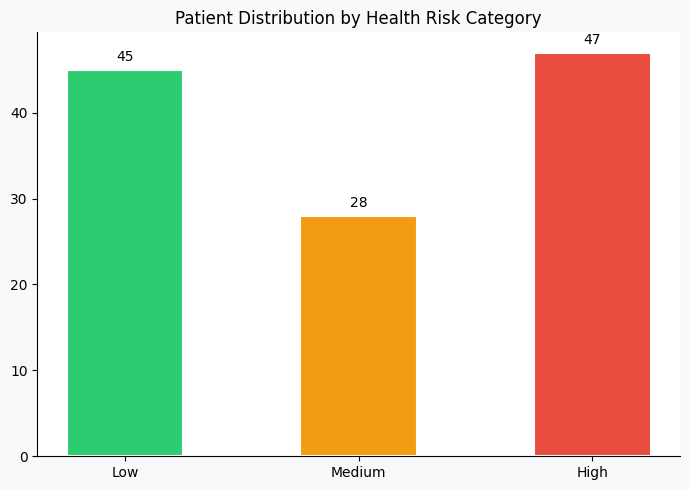

In [ ]:
risk_order = ["Low", "Medium", "High"]
colors = [PALETTE[r] for r in risk_order]

fig, ax = plt.subplots(figsize=(7, 5))

counts = df["health_risk_category"].value_counts().reindex(risk_order)

bars = ax.bar(
    counts.index,
    counts.values,
    color=colors,
    width=0.5,
    edgecolor="white",
    linewidth=1.5
)

for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        str(val),
        ha="center"
    )

ax.set_title("Patient Distribution by Health Risk Category")

plt.tight_layout()

plt.savefig("visualizations/01_risk_distribution.png", dpi=150)

plt.show()

Chart 2: Age vs BMI Scatter Plot

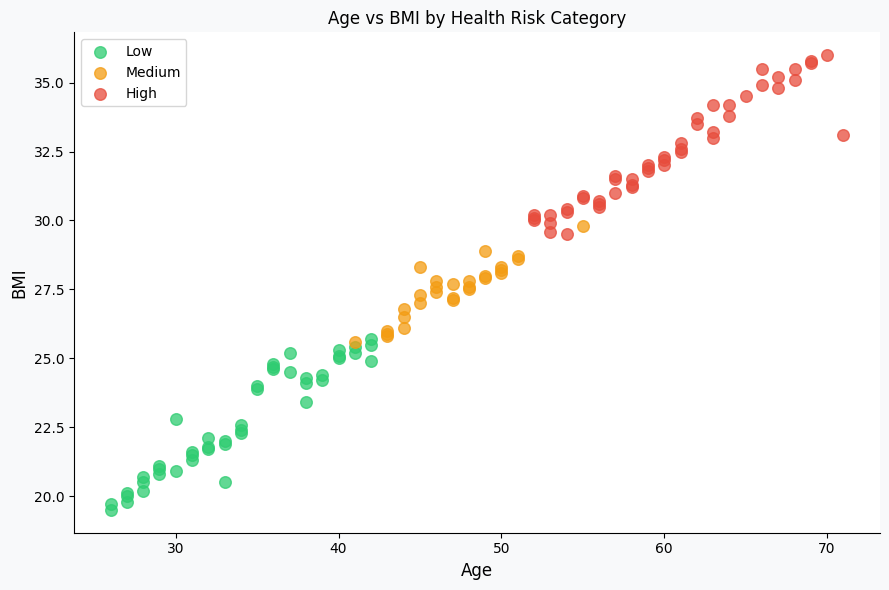

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for risk in risk_order:
    subset = df[df["health_risk_category"] == risk]

    ax.scatter(
        subset["age"],
        subset["bmi"],
        c=PALETTE[risk],
        label=risk,
        alpha=0.75,
        s=70
    )

ax.set_title("Age vs BMI by Health Risk Category")
ax.set_xlabel("Age")
ax.set_ylabel("BMI")

ax.legend()

plt.tight_layout()

plt.savefig("visualizations/02_age_vs_bmi.png", dpi=150)

plt.show()

CHART 3: Average Metrics by Risk

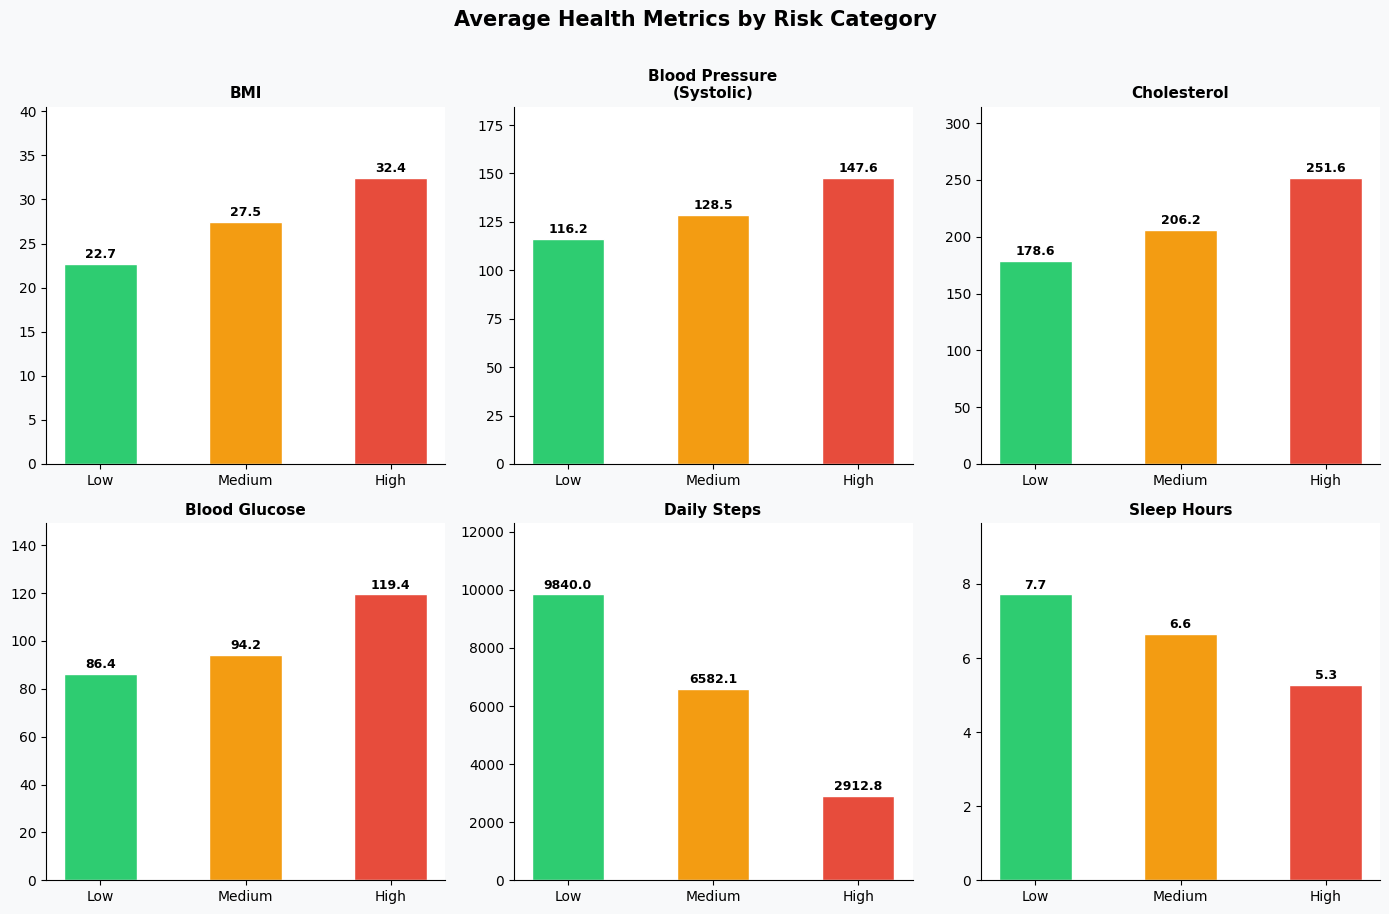

In [ ]:
metrics = {
    "BMI": "bmi",
    "Blood Pressure\n(Systolic)": "blood_pressure_systolic",
    "Cholesterol": "cholesterol_level",
    "Blood Glucose": "blood_glucose",
    "Daily Steps": "daily_steps",
    "Sleep Hours": "sleep_hours",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

fig.suptitle(
    "Average Health Metrics by Risk Category",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

for ax, (title, col) in zip(axes.flatten(), metrics.items()):

    means = df.groupby("health_risk_category")[col].mean().reindex(risk_order)

    bars = ax.bar(
        means.index,
        means.values,
        color=colors,
        edgecolor="white",
        width=0.5
    )

    for bar, val in zip(bars, means.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + means.values.max() * 0.01,
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    ax.set_title(title, fontsize=11, fontweight="bold")

    ax.set_ylim(0, means.values.max() * 1.25)

plt.tight_layout()

plt.savefig(
    "visualizations/03_metrics_by_risk.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

CHART 4: Lifestyle Factors Breakdown

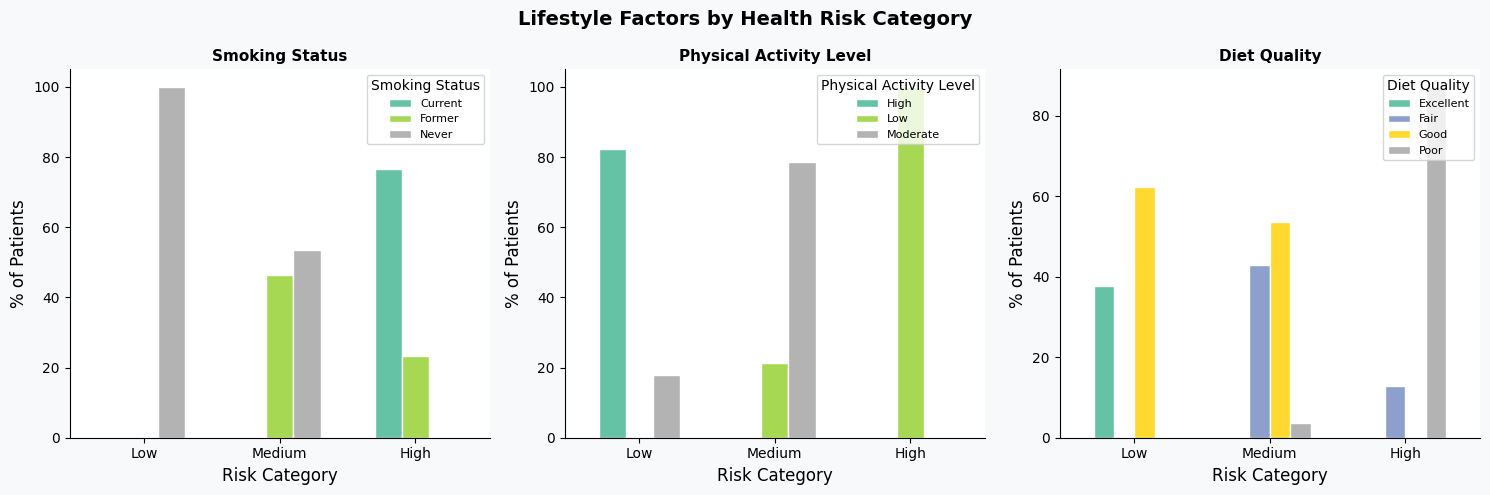

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fig.suptitle(
    "Lifestyle Factors by Health Risk Category",
    fontsize=14,
    fontweight="bold"
)

lifestyle_cols = [
    "smoking_status",
    "physical_activity_level",
    "diet_quality"
]

titles = [
    "Smoking Status",
    "Physical Activity Level",
    "Diet Quality"
]

for ax, col, title in zip(axes, lifestyle_cols, titles):

    cross = (
        df.groupby(["health_risk_category", col])
        .size()
        .unstack(fill_value=0)
    )

    cross = cross.reindex(risk_order)

    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

    cross_pct.plot(
        kind="bar",
        ax=ax,
        colormap="Set2",
        edgecolor="white",
        width=0.6
    )

    ax.set_title(title, fontsize=11, fontweight="bold")

    ax.set_xlabel("Risk Category")
    ax.set_ylabel("% of Patients")

    ax.set_xticklabels(risk_order, rotation=0)

    ax.legend(
        title=col.replace("_", " ").title(),
        fontsize=8,
        loc="upper right"
    )

plt.tight_layout()

plt.savefig("visualizations/04_lifestyle_breakdown.png", dpi=150)

plt.show()

CHART 5: Correlation Heatmap

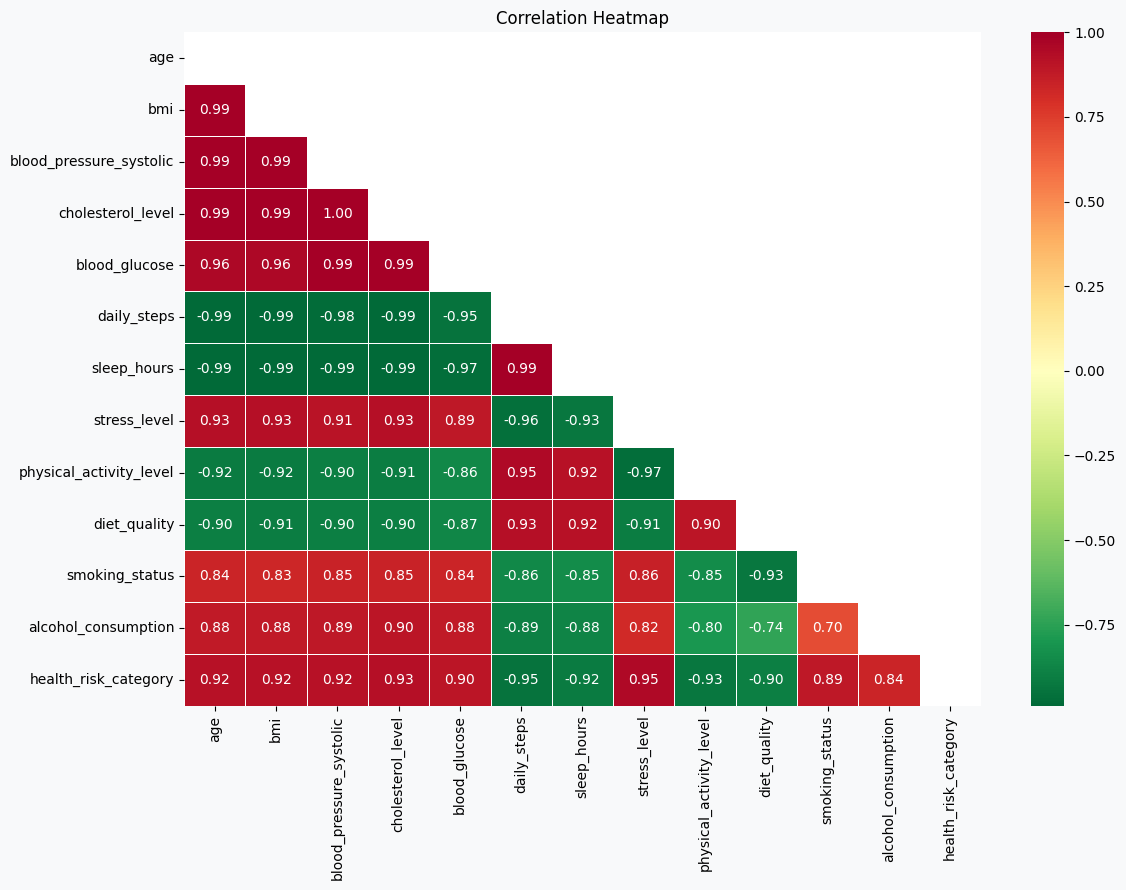

In [ ]:
corr_cols = [
    "age",
    "bmi",
    "blood_pressure_systolic",
    "cholesterol_level",
    "blood_glucose",
    "daily_steps",
    "sleep_hours",
    "stress_level",
    "physical_activity_level",
    "diet_quality",
    "smoking_status",
    "alcohol_consumption",
    "health_risk_category"
]

corr_matrix = df_encoded[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    center=0,
    linewidths=0.5
)

ax.set_title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("visualizations/05_correlation_heatmap.png", dpi=150)

plt.show()

CHART 6: Daily Steps Distribution

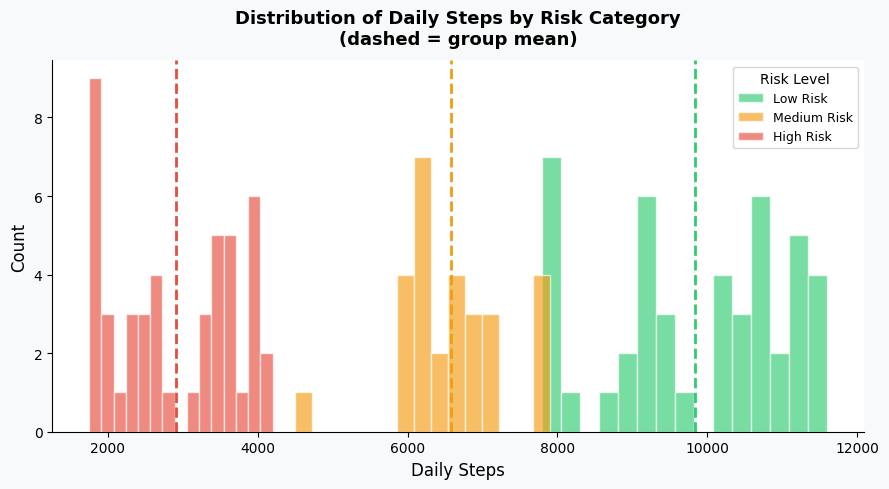

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for risk in risk_order:

    subset = df[df["health_risk_category"] == risk]["daily_steps"]

    ax.hist(
        subset,
        bins=15,
        alpha=0.65,
        label=f"{risk} Risk",
        color=PALETTE[risk],
        edgecolor="white"
    )

    ax.axvline(
        subset.mean(),
        color=PALETTE[risk],
        linestyle="--",
        linewidth=2
    )

ax.set_title(
    "Distribution of Daily Steps by Risk Category\n(dashed = group mean)",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Daily Steps")
ax.set_ylabel("Count")

ax.legend(title="Risk Level", fontsize=9)

plt.tight_layout()

plt.savefig("visualizations/06_daily_steps_distribution.png", dpi=150)

plt.show()

CHART 7: Family History Impact

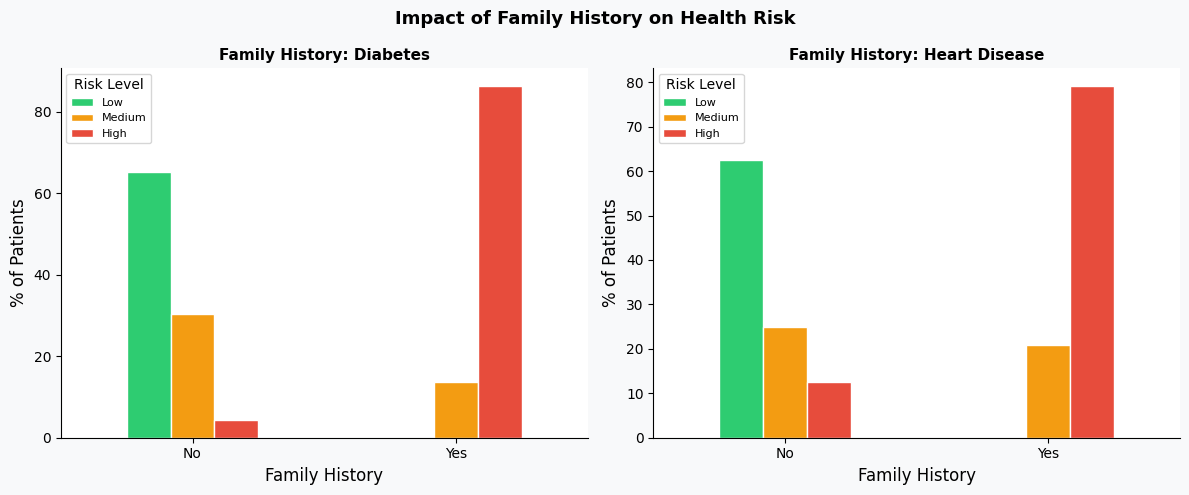

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(
    "Impact of Family History on Health Risk",
    fontsize=13,
    fontweight="bold"
)

for ax, col, title in zip(
    axes,
    ["family_history_diabetes", "family_history_heart_disease"],
    ["Family History: Diabetes", "Family History: Heart Disease"]
):

    cross = (
        df.groupby([col, "health_risk_category"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=risk_order)
    )

    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

    cross_pct.plot(
        kind="bar",
        ax=ax,
        color=[PALETTE[r] for r in risk_order],
        edgecolor="white",
        width=0.5
    )

    ax.set_title(title, fontsize=11, fontweight="bold")

    ax.set_xlabel("Family History")
    ax.set_ylabel("% of Patients")

    ax.set_xticklabels(["No", "Yes"], rotation=0)

    ax.legend(title="Risk Level", fontsize=8)

plt.tight_layout()

plt.savefig("visualizations/07_family_history_impact.png", dpi=150)

plt.show()

CHART 8: Age Group Risk Profile

/tmp/ipykernel_6047/2864064512.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["age_group", "health_risk_category"])


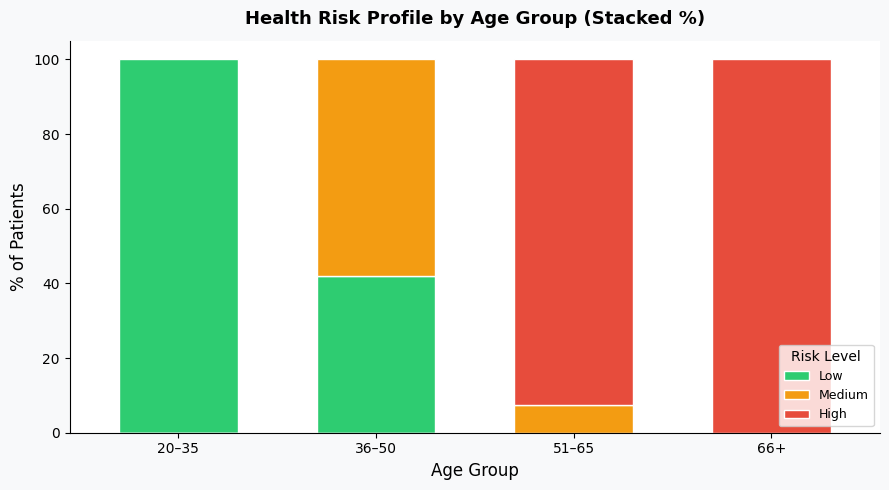

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

age_risk = (
    df.groupby(["age_group", "health_risk_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=risk_order)
)

age_risk_pct = age_risk.div(age_risk.sum(axis=1), axis=0) * 100

age_risk_pct.plot(
    kind="bar",
    ax=ax,
    color=[PALETTE[r] for r in risk_order],
    edgecolor="white",
    width=0.6,
    stacked=True
)

ax.set_title(
    "Health Risk Profile by Age Group (Stacked %)",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Age Group")
ax.set_ylabel("% of Patients")

ax.set_xticklabels(age_risk_pct.index, rotation=0)

ax.legend(
    title="Risk Level",
    fontsize=9,
    loc="lower right"
)

plt.tight_layout()

plt.savefig("visualizations/08_age_group_risk_profile.png", dpi=150)

plt.show()

Key Findings Summary

In [ ]:
high_risk = df[df["health_risk_category"] == "High"]
low_risk  = df[df["health_risk_category"] == "Low"]

print(f"""

KEY FINDINGS — HEALTH RISK EDA

Total Patients Analysed : {len(df):>5}

High Risk Patients      : {len(high_risk):>5} ({len(high_risk)/len(df)*100:.0f}%)

Low Risk Patients       : {len(low_risk):>5} ({len(low_risk)/len(df)*100:.0f}%)


FINDING 1: PHYSICAL INACTIVITY IS THE STRONGEST RISK

High risk avg daily steps : {high_risk['daily_steps'].mean():>6.0f}

Low risk avg daily steps  : {low_risk['daily_steps'].mean():>6.0f}

→ {(1 - high_risk['daily_steps'].mean()/low_risk['daily_steps'].mean())*100:.0f}% fewer steps in high-risk group


FINDING 2: BMI & BLOOD PRESSURE SPIKE IN HIGH-RISK

High risk avg BMI : {high_risk['bmi'].mean():>5.1f}

Low risk avg BMI  : {low_risk['bmi'].mean():>5.1f}


FINDING 3: SLEEP DEPRIVATION LINKED TO HIGH RISK

High risk avg sleep hrs : {high_risk['sleep_hours'].mean():>4.1f}

Low risk avg sleep hrs  : {low_risk['sleep_hours'].mean():>4.1f}


FINDING 4: SMOKING + FAMILY HISTORY = AMPLIFIED RISK

% current smokers (High) : {(high_risk['smoking_status']=='Current').mean()*100:>4.0f}%

% current smokers (Low)  : {(low_risk['smoking_status']=='Never').mean()*100:>4.0f}% never smoked


FINDING 5: RISK ESCALATES SHARPLY AFTER AGE 50

High risk avg age : {high_risk['age'].mean():>5.1f}

Low risk avg age  : {low_risk['age'].mean():>5.1f}

""")

print("All visualizations saved to: visualizations/")
print("Analysis complete!")



KEY FINDINGS — HEALTH RISK EDA

Total Patients Analysed :   120

High Risk Patients      :    47 (39%)

Low Risk Patients       :    45 (38%)


FINDING 1: PHYSICAL INACTIVITY IS THE STRONGEST RISK

High risk avg daily steps :   2913

Low risk avg daily steps  :   9840

→ 70% fewer steps in high-risk group


FINDING 2: BMI & BLOOD PRESSURE SPIKE IN HIGH-RISK

High risk avg BMI :  32.4

Low risk avg BMI  :  22.7


FINDING 3: SLEEP DEPRIVATION LINKED TO HIGH RISK

High risk avg sleep hrs :  5.3

Low risk avg sleep hrs  :  7.7


FINDING 4: SMOKING + FAMILY HISTORY = AMPLIFIED RISK

% current smokers (High) :   77%

% current smokers (Low)  :  100% never smoked


FINDING 5: RISK ESCALATES SHARPLY AFTER AGE 50

High risk avg age :  60.1

Low risk avg age  :  33.9


All visualizations saved to: visualizations/
Analysis complete!
